# Resume–Job Matching with Text Embeddings
CS 4650 Final Project — Aniya Pauling, Huang Tian, Andre Koga, Kishan Patel

In [41]:
!pip install datasets scikit-learn -q

## 1. Data Loading & Preprocessing

We use the `0xnbk/resume-ats-score-v1-en` dataset from Hugging Face, which contains 6,374 resume–job description pairs. Each row stores a resume and a job description concatenated in a single `text` field separated by the token `SEP`. We parse each row to extract the resume and job description as separate fields, alongside the continuous ATS compatibility score (18.3–90.7) and a 3-class categorical label (`"No Fit"`, `"Potential Fit"`, `"Good Fit"`). The dataset is pre-split into 5,099 training rows and 1,275 validation rows.

In [42]:
from datasets import load_dataset
import pandas as pd

raw = load_dataset("0xnbk/resume-ats-score-v1-en")
print(raw)

DatasetDict({
    train: Dataset({
        features: ['text', 'ats_score', 'original_label'],
        num_rows: 5099
    })
    validation: Dataset({
        features: ['text', 'ats_score', 'original_label'],
        num_rows: 1275
    })
})


In [43]:
# Find the actual separator — search the full text
sample = raw["train"][0]
print("Keys:", list(sample.keys()))
print("ats_score:", sample["ats_score"])
print("original_label:", sample["original_label"])
print(f"Full text length: {len(sample['text'])} chars")
print()

# Print a window around the middle of the text to find the separator
text = sample["text"]
mid = len(text) // 2
print(f"--- chars 400-600 ---")
print(repr(text[400:600]))
print()
print(f"--- chars {mid-100}:{mid+100} ---")
print(repr(text[mid-100:mid+100]))
print()

# Search for any non-alphanumeric/punctuation patterns that look like a separator
import re
special = re.findall(r'[^\w\s.,!?;:\'\"-]{2,}', text)
print("Unusual token patterns found:", list(set(special))[:20])

Keys: ['text', 'ats_score', 'original_label']
ats_score: 80.6
original_label: Good Fit
Full text length: 5324 chars

--- chars 400-600 ---
'tware applicationsStrong understanding of structured programming techniques and Software Development life Cycle (SDLC) - Agile (SCRUM)Able to learn, understand, and apply new software programs easily.'

--- chars 2562:2762 ---
'such as trends, budget data, and maintenance cycles.Design and develop workflow, test plans, and business processes to ensure functionality, completeness, and quality.Work closely with other departmen'

Unusual token patterns found: []


In [44]:
import re

def parse_row(row):
    # Use word boundary so "September" or "separate" don't trigger a false split
    parts = re.split(r'\bSEP\b', row["text"], maxsplit=1)
    resume = parts[0].strip()
    job_desc = parts[1].strip() if len(parts) > 1 else ""
    return {
        "resume": resume,
        "job_description": job_desc,
        "ats_score": row["ats_score"],
        "label": row["original_label"],
    }

train_df = pd.DataFrame([parse_row(r) for r in raw["train"]])
val_df   = pd.DataFrame([parse_row(r) for r in raw["validation"]])

print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows")
print(f"Empty job_descriptions — train: {(train_df['job_description'] == '').sum()}, val: {(val_df['job_description'] == '').sum()}")
train_df.head()

Train: 5099 rows | Val: 1275 rows
Empty job_descriptions — train: 0, val: 0


,resume,job_description,ats_score,label
0,SummaryI am seeking a position wherein I may u...,- Share resume to shan imrsoft.com Job Title J...,80.6,Good Fit
1,ProfileHighly motivated Sales Associate with e...,Purpose StatementThe Software Engineering Mana...,24.3,No Fit
2,SummaryHaving achieved a milestone of 7 years ...,"Title Business AnalystLocation Santa Clara, CA...",53.9,Potential Fit
3,SummaryWireless communications engineer with e...,Job Description As a Principal Software Engine...,52.5,Potential Fit
4,SummaryData Entry experienced and adept at inp...,"Title Data EngineerLocation fully remote, howe...",59.2,Potential Fit


## 2. Exploratory Data Analysis

Before modeling, we examine the distribution of ATS scores and class labels in the training set, and measure the length (in words) of both resumes and job descriptions. This informs key modeling decisions — in particular, resumes average ~720 words while SBERT has a default maximum sequence length of 256 tokens, meaning longer resumes will be truncated. Job descriptions average ~378 words and are less affected by this limit.

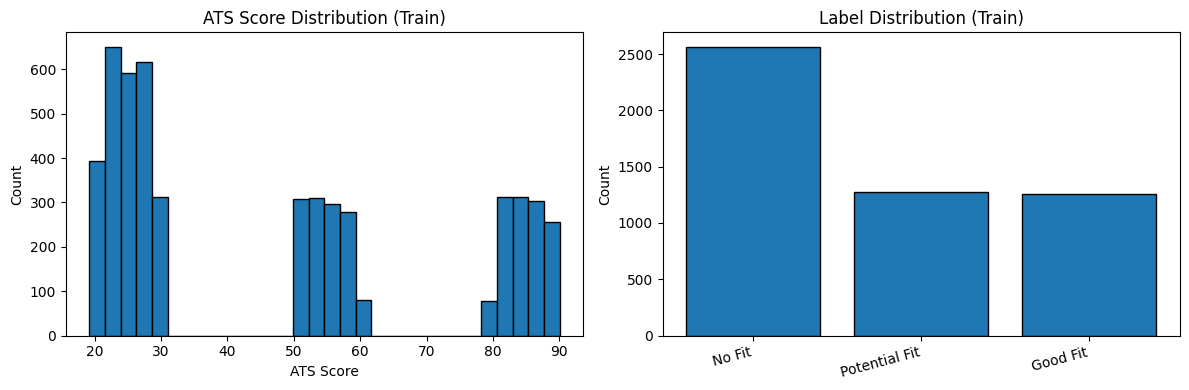

Label values: <ArrowStringArray>
['Good Fit', 'No Fit', 'Potential Fit']
Length: 3, dtype: str
         ats_score
count  5099.000000
mean     47.187452
std      24.970249
min      19.160000
25%      24.700000
50%      29.900000
75%      59.800000
max      90.050000


In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ATS score distribution
axes[0].hist(train_df["ats_score"], bins=30, edgecolor="black")
axes[0].set_title("ATS Score Distribution (Train)")
axes[0].set_xlabel("ATS Score")
axes[0].set_ylabel("Count")

# Label distribution — labels may be strings or ints
if "label" in train_df.columns:
    counts = train_df["label"].value_counts()
    axes[1].bar(counts.index.astype(str), counts.values, edgecolor="black")
    axes[1].set_title("Label Distribution (Train)")
    axes[1].set_ylabel("Count")
    plt.setp(axes[1].get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()

print("Label values:", train_df["label"].unique() if "label" in train_df.columns else "N/A")
print(train_df[["ats_score"]].describe())

In [46]:
# Check text lengths to understand input sizes for models
train_df["resume_len"]   = train_df["resume"].str.split().str.len()
train_df["job_desc_len"] = train_df["job_description"].str.split().str.len()

print("Resume word count:")
print(train_df["resume_len"].describe())
print()
print("Job description word count:")
print(train_df["job_desc_len"].describe())

Resume word count:
count    5099.000000
mean      723.016278
std       378.082746
min         4.000000
25%       511.000000
50%       634.000000
75%       829.000000
max      2057.000000
Name: resume_len, dtype: float64

Job description word count:
count    5099.000000
mean      375.370073
std       242.407497
min        11.000000
25%       172.000000
50%       327.000000
75%       540.000000
max      1570.000000
Name: job_desc_len, dtype: float64


In [47]:
# Verify no empty parses
empty_resumes  = (train_df["resume"] == "").sum()
empty_job_desc = (train_df["job_description"] == "").sum()
print(f"Empty resumes: {empty_resumes} | Empty job descriptions: {empty_job_desc}")

# Print one example pair
print("\n--- Sample resume (first 300 chars) ---")
print(train_df["resume"].iloc[0][:300])
print("\n--- Sample job description (first 300 chars) ---")
print(train_df["job_description"].iloc[0][:300])

label_val = train_df["label"].iloc[0] if "label" in train_df.columns else "N/A"
print(f"\nATS score: {train_df['ats_score'].iloc[0]} | Label: {label_val}")

Empty resumes: 0 | Empty job descriptions: 0

--- Sample resume (first 300 chars) ---
SummaryI am seeking a position wherein I may use my proven development, technical, and analytical skills while having the opportunity to continue my learning and diversify my experiences. Highlights17 years experience in Information TechnologyHeld a Secret security clearanceExpert in business proces

--- Sample job description (first 300 chars) ---
- Share resume to shan imrsoft.com Job Title JDE Business AnalystLocation REMOTE Mandatory Skills JDE World Homebuilder Job Description Extensive experience ( 10 years) in JDE World Homebuilder, Job Cost, and Procurement module functions functionality and associated business processes. (Primary)Hand

ATS score: 80.6 | Label: Good Fit


## 3. Validation Ranking Groups

For ranking metrics, each resume needs a list of possible jobs to choose from. The dataset only gives one resume-job pair per row, so we make a small ranking task for each validation resume.

For each validation row:

- the resume is the query,
- the matching job from the same row is the correct answer,
- 49 other validation jobs are randomly sampled as incorrect options,
- the model ranks all 50 jobs.

We also check for duplicate texts across the train and validation splits. There are many duplicates in this dataset. If we removed all of them, only a very small number of validation examples would be left, so we keep the full validation set and mention the duplicates as a limitation.

In [48]:
import hashlib
import numpy as np

RNG_SEED = 42
NEGATIVES_PER_QUERY = 49
rng = np.random.default_rng(RNG_SEED)

# Make IDs so we can track each resume and job in the ranking table.
train_rank = train_df.reset_index(drop=True).copy()
val_rank = val_df.reset_index(drop=True).copy()
train_rank["resume_id"] = [f"train_{i}" for i in range(len(train_rank))]
val_rank["resume_id"] = [f"val_{i}" for i in range(len(val_rank))]
val_rank["job_id"] = [f"val_job_{i}" for i in range(len(val_rank))]


def clean_text(text):
    return " ".join(str(text).lower().split())


def text_hash(text):
    return hashlib.md5(clean_text(text).encode("utf-8")).hexdigest()


# Check how many exact duplicate resumes/jobs appear in both splits.
train_rank["resume_hash"] = train_rank["resume"].map(text_hash)
train_rank["job_hash"] = train_rank["job_description"].map(text_hash)
val_rank["resume_hash"] = val_rank["resume"].map(text_hash)
val_rank["job_hash"] = val_rank["job_description"].map(text_hash)

train_resume_hashes = set(train_rank["resume_hash"])
train_job_hashes = set(train_rank["job_hash"])

resume_overlap = len(train_resume_hashes & set(val_rank["resume_hash"]))
job_overlap = len(train_job_hashes & set(val_rank["job_hash"]))
resume_unseen_count = int((~val_rank["resume_hash"].isin(train_resume_hashes)).sum())
fully_unique_count = int(
    ((~val_rank["resume_hash"].isin(train_resume_hashes)) & (~val_rank["job_hash"].isin(train_job_hashes))).sum()
)

print("=== Duplicate Text Check ===")
print(f"Duplicate resume texts across train/val: {resume_overlap}")
print(f"Duplicate job texts across train/val:    {job_overlap}")
print(f"Rows left if duplicate resumes are removed:       {resume_unseen_count}")
print(f"Rows left if duplicate resumes and jobs removed:  {fully_unique_count}")
print("We keep the full validation set because the sets would end up being too small.")


# Use the full validation split for the main ranking setup.
val_eval_df = val_rank.copy()
val_eval_df["resume_id"] = [f"val_eval_{i}" for i in range(len(val_eval_df))]
val_eval_df["job_id"] = [f"val_eval_job_{i}" for i in range(len(val_eval_df))]

print("\n=== Ranking Setup ===")
print(f"Validation resumes used: {len(val_eval_df)}")
print(f"Random negative jobs per resume: {NEGATIVES_PER_QUERY}")


# Build one ranking group per resume.
all_val_indices = np.arange(len(val_eval_df))
rows = []

for q_idx, q in val_eval_df.iterrows():
    possible_negatives = all_val_indices[all_val_indices != q_idx]
    n_neg = min(NEGATIVES_PER_QUERY, len(possible_negatives))
    neg_indices = rng.choice(possible_negatives, size=n_neg, replace=False)

    candidate_indices = np.concatenate(([q_idx], neg_indices))
    rng.shuffle(candidate_indices)

    for cand_idx in candidate_indices:
        rows.append(
            {
                "query_id": q["resume_id"],
                "query_index": q_idx,
                "query_resume": q["resume"],
                "candidate_job_id": val_eval_df.loc[cand_idx, "job_id"],
                "candidate_index": int(cand_idx),
                "candidate_job_description": val_eval_df.loc[cand_idx, "job_description"],
                "ats_score": q["ats_score"],
                "label": q["label"],
                "is_relevant": int(cand_idx == q_idx),
            }
        )

rank_eval_df = pd.DataFrame(rows)


# Quick checks: each resume should have exactly one correct job in its candidate list.
group_sizes = rank_eval_df.groupby("query_id").size()
correct_counts = rank_eval_df.groupby("query_id")["is_relevant"].sum()
unique_candidate_counts = rank_eval_df.groupby("query_id")["candidate_job_id"].nunique()

assert (correct_counts == 1).all(), "Each resume should have exactly one correct job."
assert (unique_candidate_counts == group_sizes).all(), "There should be no duplicate jobs within a group."

print("\n=== Ranking Group Checks ===")
print(f"Number of resumes: {rank_eval_df['query_id'].nunique()}")
print(f"Jobs per resume (min/median/max): {group_sizes.min()}/{int(group_sizes.median())}/{group_sizes.max()}")
print(f"Correct jobs per resume: {sorted(int(x) for x in correct_counts.unique())}")
print("Checks passed.")

print("\nPreview:")
print(rank_eval_df[["query_id", "candidate_job_id", "is_relevant"]].head(10))

=== Duplicate Text Check ===
Duplicate resume texts across train/val: 426
Duplicate job texts across train/val:    254
Rows left if duplicate resumes are removed:       24
Rows left if duplicate resumes and jobs removed:  8
We keep the full validation set because the sets would end up being too small.

=== Ranking Setup ===
Validation resumes used: 1275
Random negative jobs per resume: 49

=== Ranking Group Checks ===
Number of resumes: 1275
Jobs per resume (min/median/max): 50/50/50
Correct jobs per resume: [1]
Checks passed.

Preview:
     query_id  candidate_job_id  is_relevant
0  val_eval_0  val_eval_job_651            0
1  val_eval_0  val_eval_job_976            0
2  val_eval_0   val_eval_job_81            0
3  val_eval_0  val_eval_job_977            0
4  val_eval_0  val_eval_job_450            0
5  val_eval_0  val_eval_job_210            0
6  val_eval_0  val_eval_job_286            0
7  val_eval_0  val_eval_job_110            0
8  val_eval_0  val_eval_job_800            0
9  val_

## 4. TF-IDF Baseline

For the first baseline, we use TF-IDF. This mainly checks word overlap between the resume and each job description.

We fit the TF-IDF vectorizer on the training resumes and job descriptions, then use it to score the validation ranking pairs from `rank_eval_df`. Higher cosine similarity means TF-IDF thinks the job is a better match for the resume.

The code below takes a bit to run so be patient (a couple minutes approx.)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# Learn TF-IDF weights from the training texts.
train_text_for_tfidf = pd.concat(
    [train_df["resume"], train_df["job_description"]],
    ignore_index=True,
)

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
tfidf_vectorizer.fit(train_text_for_tfidf)

# Convert each resume/job pair into TF-IDF vectors.
resume_vectors = tfidf_vectorizer.transform(rank_eval_df["query_resume"])
job_vectors = tfidf_vectorizer.transform(rank_eval_df["candidate_job_description"])

# After normalizing, cosine similarity is just the dot product.
resume_vectors = normalize(resume_vectors, norm="l2", axis=1)
job_vectors = normalize(job_vectors, norm="l2", axis=1)
tfidf_scores = np.asarray(resume_vectors.multiply(job_vectors).sum(axis=1)).ravel()

tfidf_ranked_df = rank_eval_df.copy()
tfidf_ranked_df["tfidf_score"] = tfidf_scores

# Rank 1 means TF-IDF thinks this is the best job for that resume.
tfidf_ranked_df["tfidf_rank"] = (
    tfidf_ranked_df.sort_values(
        ["query_id", "tfidf_score", "candidate_job_id"],
        ascending=[True, False, True],
    )
    .groupby("query_id")
    .cumcount()
    + 1
)

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Resume-job pairs scored: {len(tfidf_ranked_df):,}")

tfidf_ranked_df.sort_values(["query_id", "tfidf_rank"])[
    ["query_id", "candidate_job_id", "is_relevant", "tfidf_score", "tfidf_rank"]
].head(10)

TF-IDF vocabulary size: 276,950
Resume-job pairs scored: 63,750


,query_id,candidate_job_id,is_relevant,tfidf_score,tfidf_rank
34,val_eval_0,val_eval_job_249,0,0.028725,1
20,val_eval_0,val_eval_job_804,0,0.028143,2
14,val_eval_0,val_eval_job_1045,0,0.026147,3
10,val_eval_0,val_eval_job_0,1,0.023381,4
30,val_eval_0,val_eval_job_1046,0,0.023381,5
9,val_eval_0,val_eval_job_117,0,0.023381,6
28,val_eval_0,val_eval_job_806,0,0.023381,7
41,val_eval_0,val_eval_job_1207,0,0.021719,8
2,val_eval_0,val_eval_job_81,0,0.021596,9
47,val_eval_0,val_eval_job_561,0,0.021052,10


In [40]:
def get_ranking_metrics(ranked_df, rank_col, model_name, ks=(1, 3, 5, 10)):
    # First get the rank of the correct job for each resume.
    correct_ranks = ranked_df.loc[
        ranked_df["is_relevant"] == 1,
        ["query_id", rank_col, "label", "ats_score"],
    ].copy()

    if len(correct_ranks) != ranked_df["query_id"].nunique():
        raise ValueError("There should be one correct job for each resume.")

    correct_ranks[rank_col] = correct_ranks[rank_col].astype(int)

    results = []

    # MRR gives more credit when the correct job is near the top.
    mrr = (1 / correct_ranks[rank_col]).mean()
    results.append({"model": model_name, "metric": "MRR", "value": mrr})

    # Top-k accuracy checks if the correct job appears in the first k results.
    for k in ks:
        top_k_acc = correct_ranks[rank_col].le(k).mean()
        results.append({"model": model_name, "metric": f"Top-{k} Accuracy", "value": top_k_acc})

    # Since there is one correct job, NDCG depends only on where that job was ranked.
    for k in ks:
        ndcg = np.where(
            correct_ranks[rank_col].le(k),
            1 / np.log2(correct_ranks[rank_col] + 1),
            0,
        ).mean()
        results.append({"model": model_name, "metric": f"NDCG@{k}", "value": ndcg})

    return pd.DataFrame(results), correct_ranks


tfidf_metrics, tfidf_correct_ranks = get_ranking_metrics(
    tfidf_ranked_df,
    rank_col="tfidf_rank",
    model_name="TF-IDF",
)

print("Rank of the correct job using TF-IDF:")
print(tfidf_correct_ranks["tfidf_rank"].describe())

print("\nTF-IDF metrics:")
display(tfidf_metrics.assign(value=tfidf_metrics["value"].round(4)))

Rank of the correct job using TF-IDF:
count    1275.000000
mean       20.713725
std        14.738232
min         1.000000
25%         7.000000
50%        18.000000
75%        33.000000
max        50.000000
Name: tfidf_rank, dtype: float64

TF-IDF metrics:


,model,metric,value
0,TF-IDF,MRR,0.1464
1,TF-IDF,Top-1 Accuracy,0.0518
2,TF-IDF,Top-3 Accuracy,0.1302
3,TF-IDF,Top-5 Accuracy,0.2094
4,TF-IDF,Top-10 Accuracy,0.3286
5,TF-IDF,NDCG@1,0.0518
6,TF-IDF,NDCG@3,0.0963
7,TF-IDF,NDCG@5,0.1286
8,TF-IDF,NDCG@10,0.1667
